In [1]:
# load quicc-dynavis from local path
import sys
import importlib
import numpy as np
sys.path.append('/Users/yuanlonghui/quicc-dynavis/src')
from quicc_dynavis import spectra, timeseries, fields_snapshot 

In [2]:
# specify folders for loading data and saving results
basefolder = "/Users/yuanlonghui/IlessDyn_Lin"
result_dir = basefolder+'/Data/IlessDyn_Lin_E2e-6/simu_quicc' + '/N137_dt5e-9'
save_dir   = basefolder+"/Results/IlessDyn_Lin_E2e-6"

### Spectral

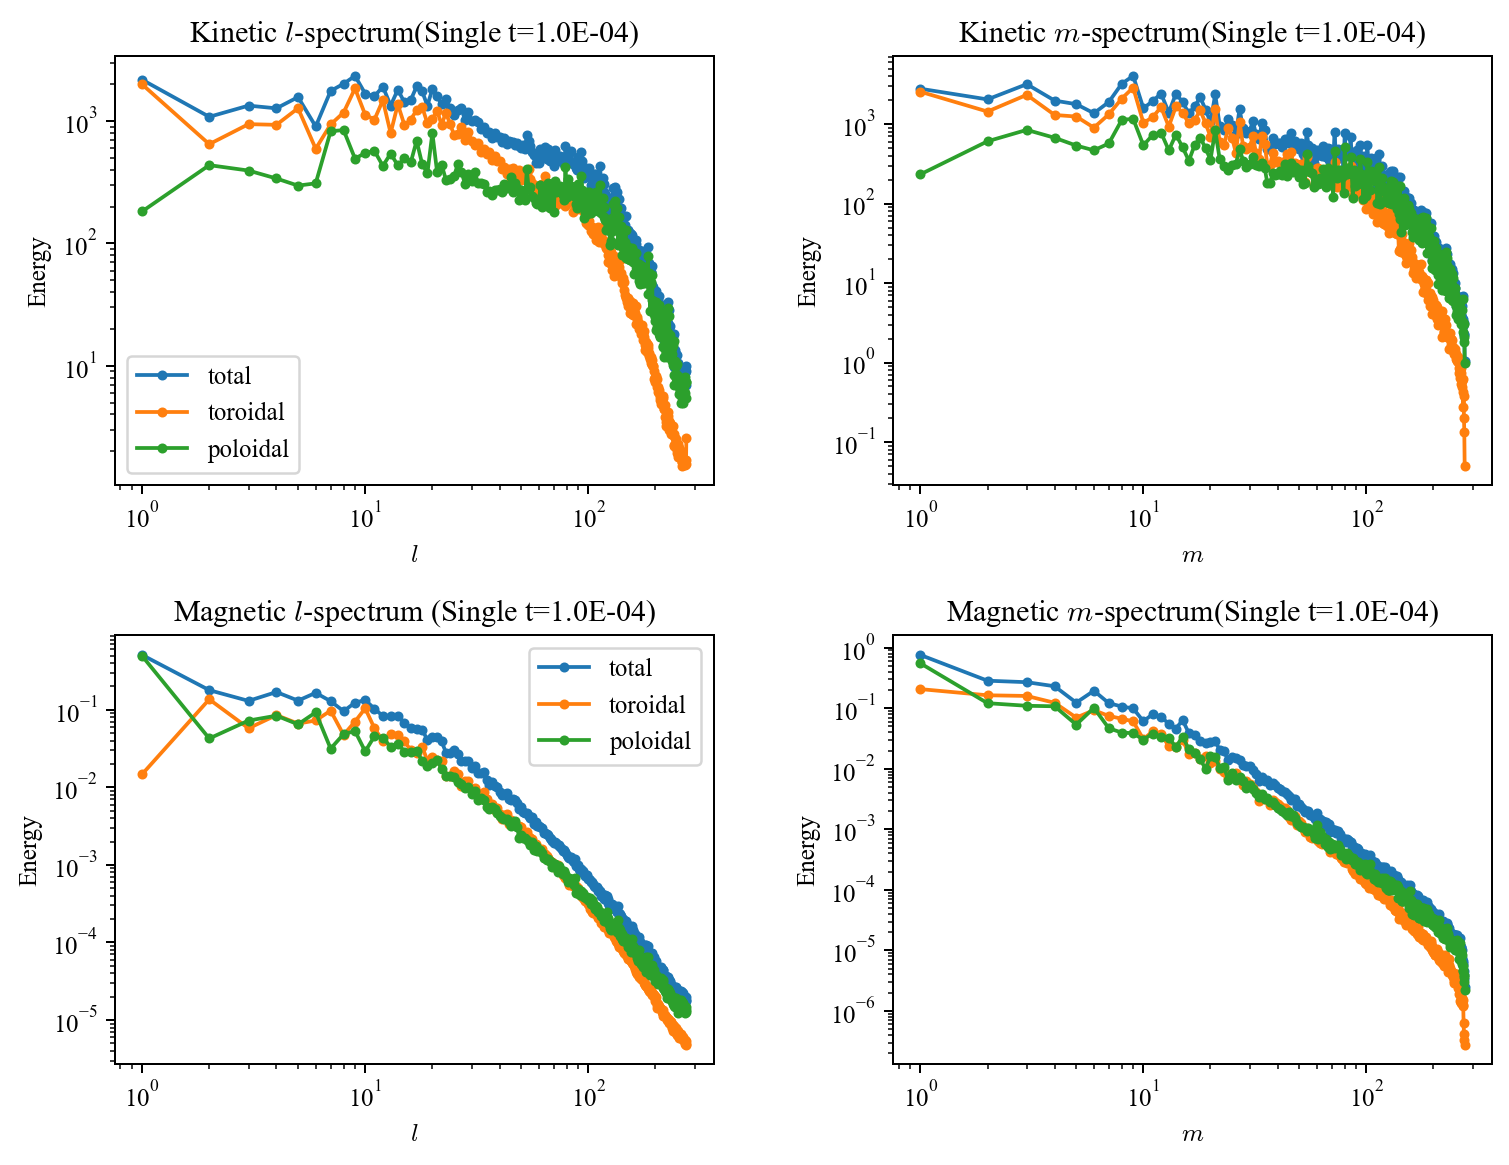

In [3]:
fig, axes, path = spectra.plot_spectra(
    folderFile=result_dir,
    save_dir = save_dir+'/spectra',
    mode="single",   # "single" or "average": #mode = 'average', start_time=0, stop_time=1,
    which="last",    # if single: "first", "last", or index (e.g. 10  
)

### time series

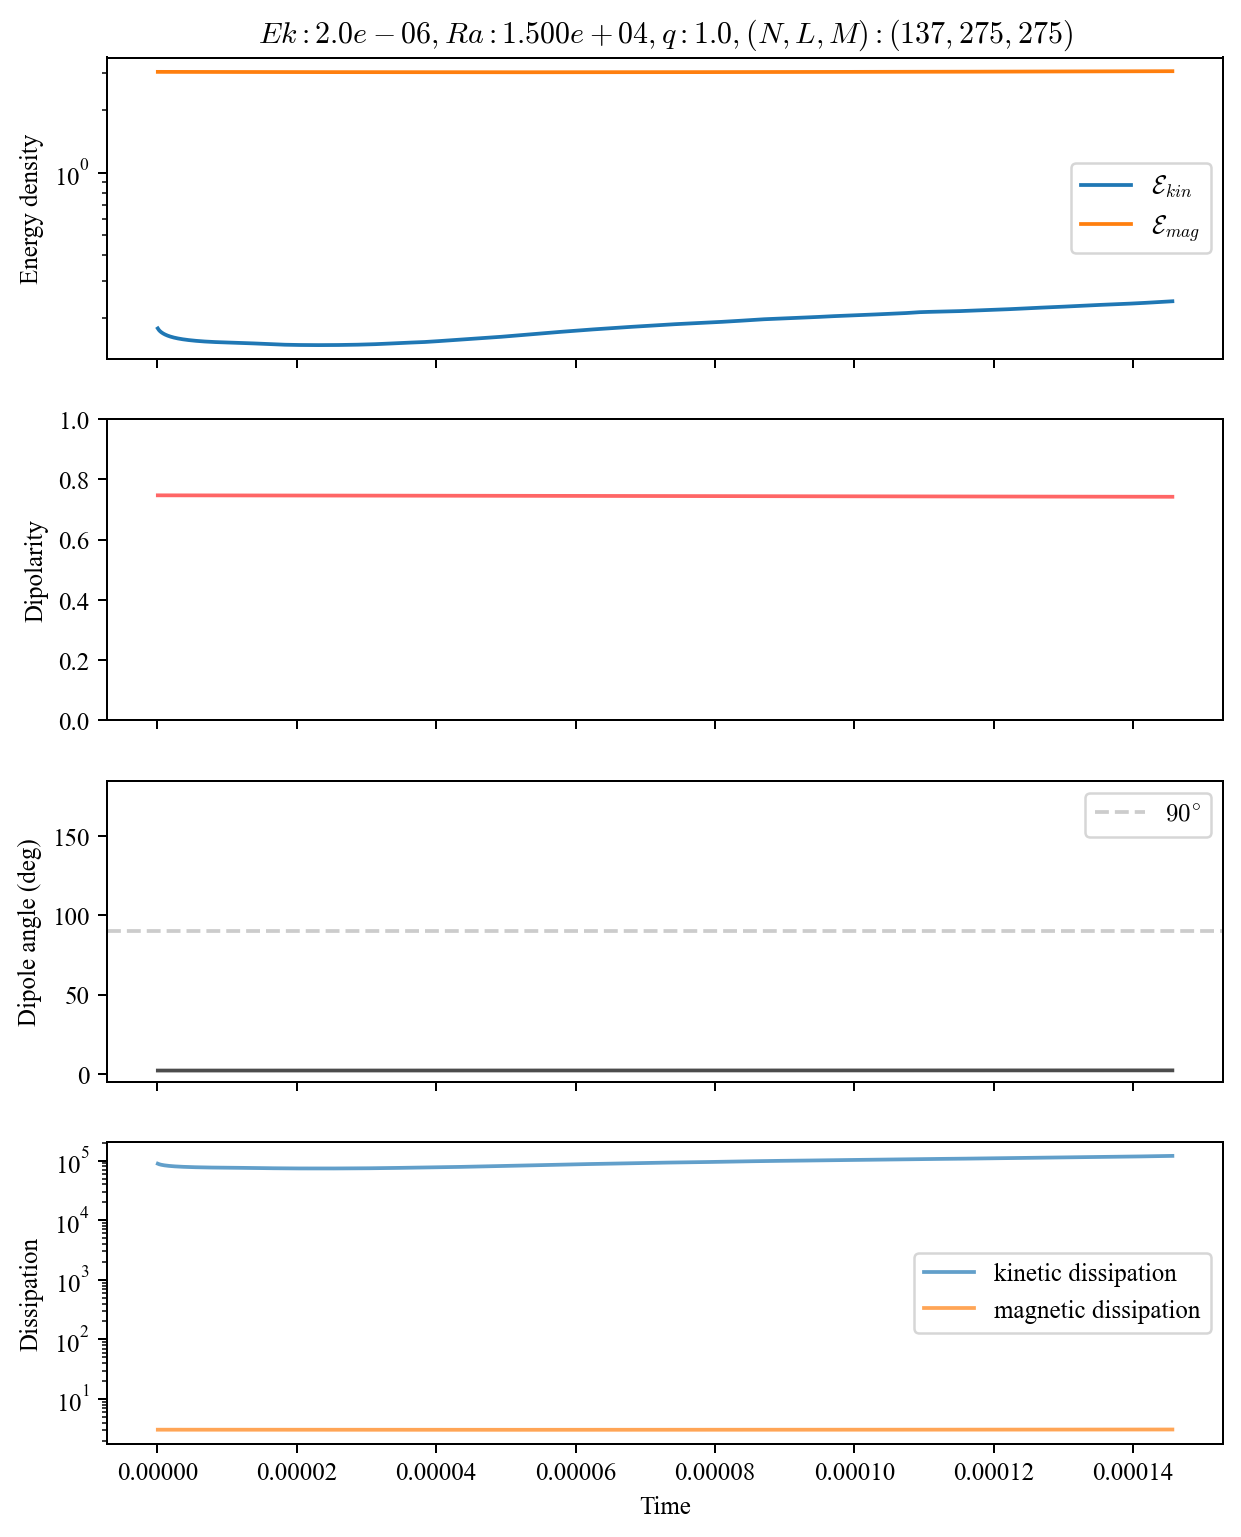

In [4]:
fig, path = timeseries.plot_energy_timeseries(
    folderFile=result_dir,
    save_dir = save_dir+'/timeseries',
)

# Snapshot of physical fields

### example

In [5]:
# specify folders for loading data and saving results
basefolder = "/Users/yuanlonghui/IlessDyn"
filepath   = basefolder+'/Data/IlessDyn'+'/CattaneoHuges/E1e-3/Ra500q20/run0/Visu/vis_fields.npz'
save_dir   = basefolder+"/Results/CattaneoHuges"

data = np.load(filepath)

### radial velocity at the equatotial plane

/Users/yuanlonghui/quicc-dynavis/src/quicc_dynavis/fields_snapshot.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(X, Y, field, shading="auto", cmap=cmap)


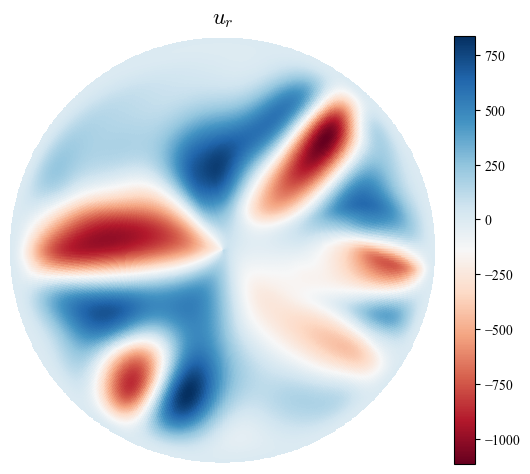

In [6]:
fields_snapshot.plot_equatorial(data,'u_r',cmap='RdBu',savefig = save_dir) # specificy the field to plot i.e. 'u_r', 'B_theta', 'T' ...

### temperature at the meridional plane

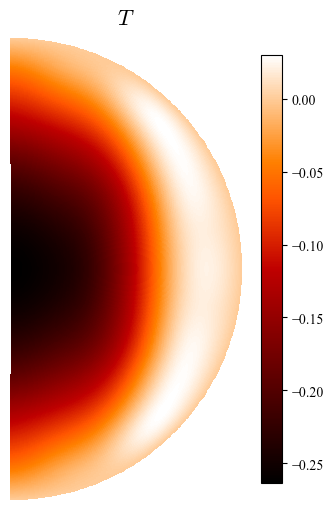

In [27]:
fields_snapshot.plot_meridional(data,'T',cmap='gist_heat',savefig = save_dir)

### Plot a few fields in a single plot

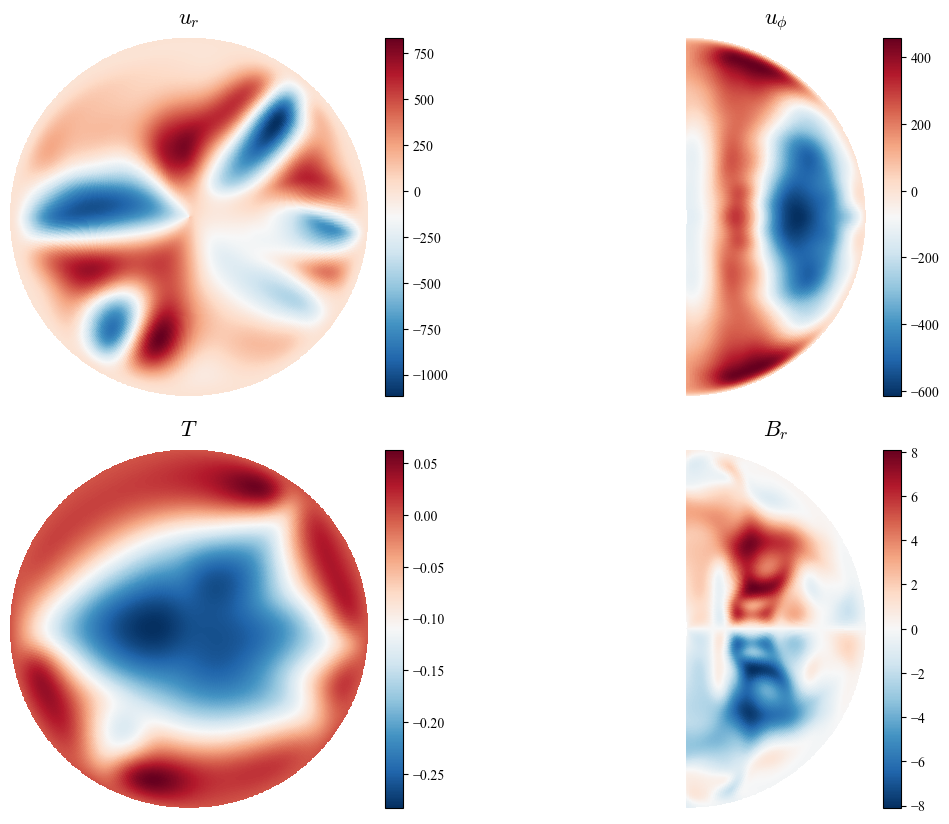

In [30]:
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, wspace=0.15, hspace=0.15)

# equatorial slice
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[1,0])
ax3 = fig.add_subplot(gs[1,1])


fields_snapshot.plot_equatorial(data, "u_r", ax=ax0)
fields_snapshot.plot_meridional(data, "u_phi",  ax=ax1)
fields_snapshot.plot_equatorial(data, "T", ax=ax2)
fields_snapshot.plot_meridional(data, "B_r", ax=ax3)


plt.show()
fig.savefig(save_dir+'/few_fields.png', dpi=180)
